In [4]:
import pandas as pd

In [5]:
from utils.visualisations import *

In [7]:
cci_df = pd.read_excel(r'data/CCI_scenarios/Extracted_data.xlsx', sheet_name='CCI_prod_data')

In [8]:
cci_df

,Mineral,Year,Scenario,Value,Unit,Value_t_mining,Value_t_refining
0,Cobalt,2018,Existing production,4.136100,kilotonnes,4136.100000,1817.181330
1,Cobalt,2019,Existing production,3.433000,kilotonnes,3433.000000,1508.276760
2,Cobalt,2020,Existing production,3.236324,kilotonnes,3236.324000,1421.867835
3,Cobalt,2021,Existing production,3.808657,kilotonnes,3808.657000,1673.320373
4,Cobalt,2022,Existing production,2.536143,kilotonnes,2536.143000,1114.245717
...,...,...,...,...,...,...,...
271,Neodymium,2036,Production potential,0.112112,kilotonnes,112.111990,67.103949
272,Neodymium,2037,Production potential,0.157056,kilotonnes,157.056451,94.005183
273,Neodymium,2038,Production potential,0.220019,kilotonnes,220.018652,131.690825
274,Neodymium,2039,Production potential,0.308222,kilotonnes,308.221705,184.484225


In [11]:
cci_df.columns

Index(['Mineral', 'Year', 'Scenario', 'Value', 'Unit', 'Value_t_mining',
       'Value_t_refining'],
      dtype='object')

In [8]:
# df_long = df.melt(
#         id_vars=["Scenario", "Year", "Unit"],
#         var_name="Metal",
#         value_name="Value"
#     )
#
#     # --- Clean ordering ---
# metals = df_long["Metal"].unique().tolist()
# df_long["Metal"] = pd.Categorical(df_long["Metal"], categories=metals, ordered=True)

In [9]:
color_map = {
    'Copper': '#8c510a',
    'Nickel': '#d8b365',
    'Graphite': '#f6e8c3',
    'Cobalt': '#c7eae5',
    'Lithium': '#5ab4ac',
    'Neodymium': '#01665e'
}

In [12]:
def plot_metal_scenarios_panels(df, color_map, value_col="Value",
                                figsize=(10, 7), dpi=350, savepath=None):
    """
    Works with a LONG dataframe of the form:

    Mineral | Year | Scenario | Value | Unit | ...

    Creates:
    - Top panel: line chart for all metals and scenarios
    - Bottom panels: stacked area for each scenario
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ---- Extract required fields ----
    minerals = df["Mineral"].unique().tolist()
    scenarios = df["Scenario"].unique().tolist()
    years = sorted(df["Year"].unique())
    unit = df["Unit"].iloc[0]

    # Auto line styles
    if len(scenarios) == 2:
        scenario_styles = {
            scenarios[0]: {"linestyle": "-", "label": f"{scenarios[0]}"},
            scenarios[1]: {"linestyle": "--", "label": f"{scenarios[1]}"}
        }
    else:
        scenario_styles = {s: {"linestyle": "-", "label": s} for s in scenarios}

    # ---- Figure layout ----
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])
    ax_top = fig.add_subplot(gs[0, :])
    ax_bottom_left = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_bottom_right = fig.add_subplot(gs[1, 1], sharex=ax_top)

    # =======================================================
    # 1️⃣ Top panel — line chart
    # =======================================================
    for mineral in minerals:
        for scen in scenarios:
            dsub = df[(df["Mineral"] == mineral) & (df["Scenario"] == scen)]
            ax_top.plot(
                dsub["Year"],
                dsub[value_col],
                color=color_map.get(mineral, "#cccccc"),
                linestyle=scenario_styles[scen]["linestyle"],
                linewidth=1.8,
                alpha=0.9,
            )

    ax_top.set_title("Production by Mineral and Scenario", fontsize=12, fontweight="bold")
    ax_top.set_ylabel(f"{value_col} ({unit})", fontsize=10)
    ax_top.set_ylim(bottom=0)
    ax_top.tick_params(labelsize=9)

    xticks = np.arange(min(years), max(years) + 1, 5)
    ax_top.set_xticks(xticks)

    scen_handles = [
        plt.Line2D([0], [0], color="black",
                   linestyle=scenario_styles[s]["linestyle"],
                   label=scenario_styles[s]["label"])
        for s in scenarios
    ]
    ax_top.legend(handles=scen_handles, loc="upper left", fontsize=11, frameon=False)

    # =======================================================
    # 2️⃣ Bottom panels — stacked area per scenario
    # =======================================================
    bottom_axes = [ax_bottom_left, ax_bottom_right]
    y_max = 0

    # Compute global max
    for scen in scenarios:
        d_scen = df[df["Scenario"] == scen]
        pivot = d_scen.pivot_table(
            index="Year", columns="Mineral", values=value_col, fill_value=0
        )
        y_max = max(y_max, pivot.sum(axis=1).max())

    for ax, scen in zip(bottom_axes, scenarios):
        d_scen = df[df["Scenario"] == scen]
        pivot = d_scen.pivot_table(
            index="Year", columns="Mineral", values=value_col, fill_value=0
        )

        cols = [color_map.get(c, "#cccccc") for c in pivot.columns]
        ax.stackplot(pivot.index, pivot.T, labels=pivot.columns, colors=cols, alpha=0.9)
        ax.set_title(scen, fontsize=11, fontweight="bold")
        ax.set_ylabel(f"{value_col} ({unit})", fontsize=9)
        ax.set_ylim(0, y_max * 1.05)
        ax.tick_params(labelsize=9)
        ax.set_xticks(xticks)

    # Remove 0 ticks
    for a in [ax_top, ax_bottom_left, ax_bottom_right]:
        a.set_yticks([y for y in a.get_yticks() if y != 0])

    # =======================================================
    # Legend (minerals)
    # =======================================================
    handles, labels = ax_bottom_right.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=min(len(labels), 6),
        fontsize=12,
        frameon=False,
    )

    plt.subplots_adjust(hspace=0.35, bottom=0.13, top=0.93, wspace=0.25)

    if savepath:
        fig.savefig(f"{savepath}.png", bbox_inches="tight")
        fig.savefig(f"{savepath}.svg", bbox_inches="tight")
        print(f"Saved to {savepath}.png and .svg")


Saved to results/Production/production_scenario_mining.png and .svg


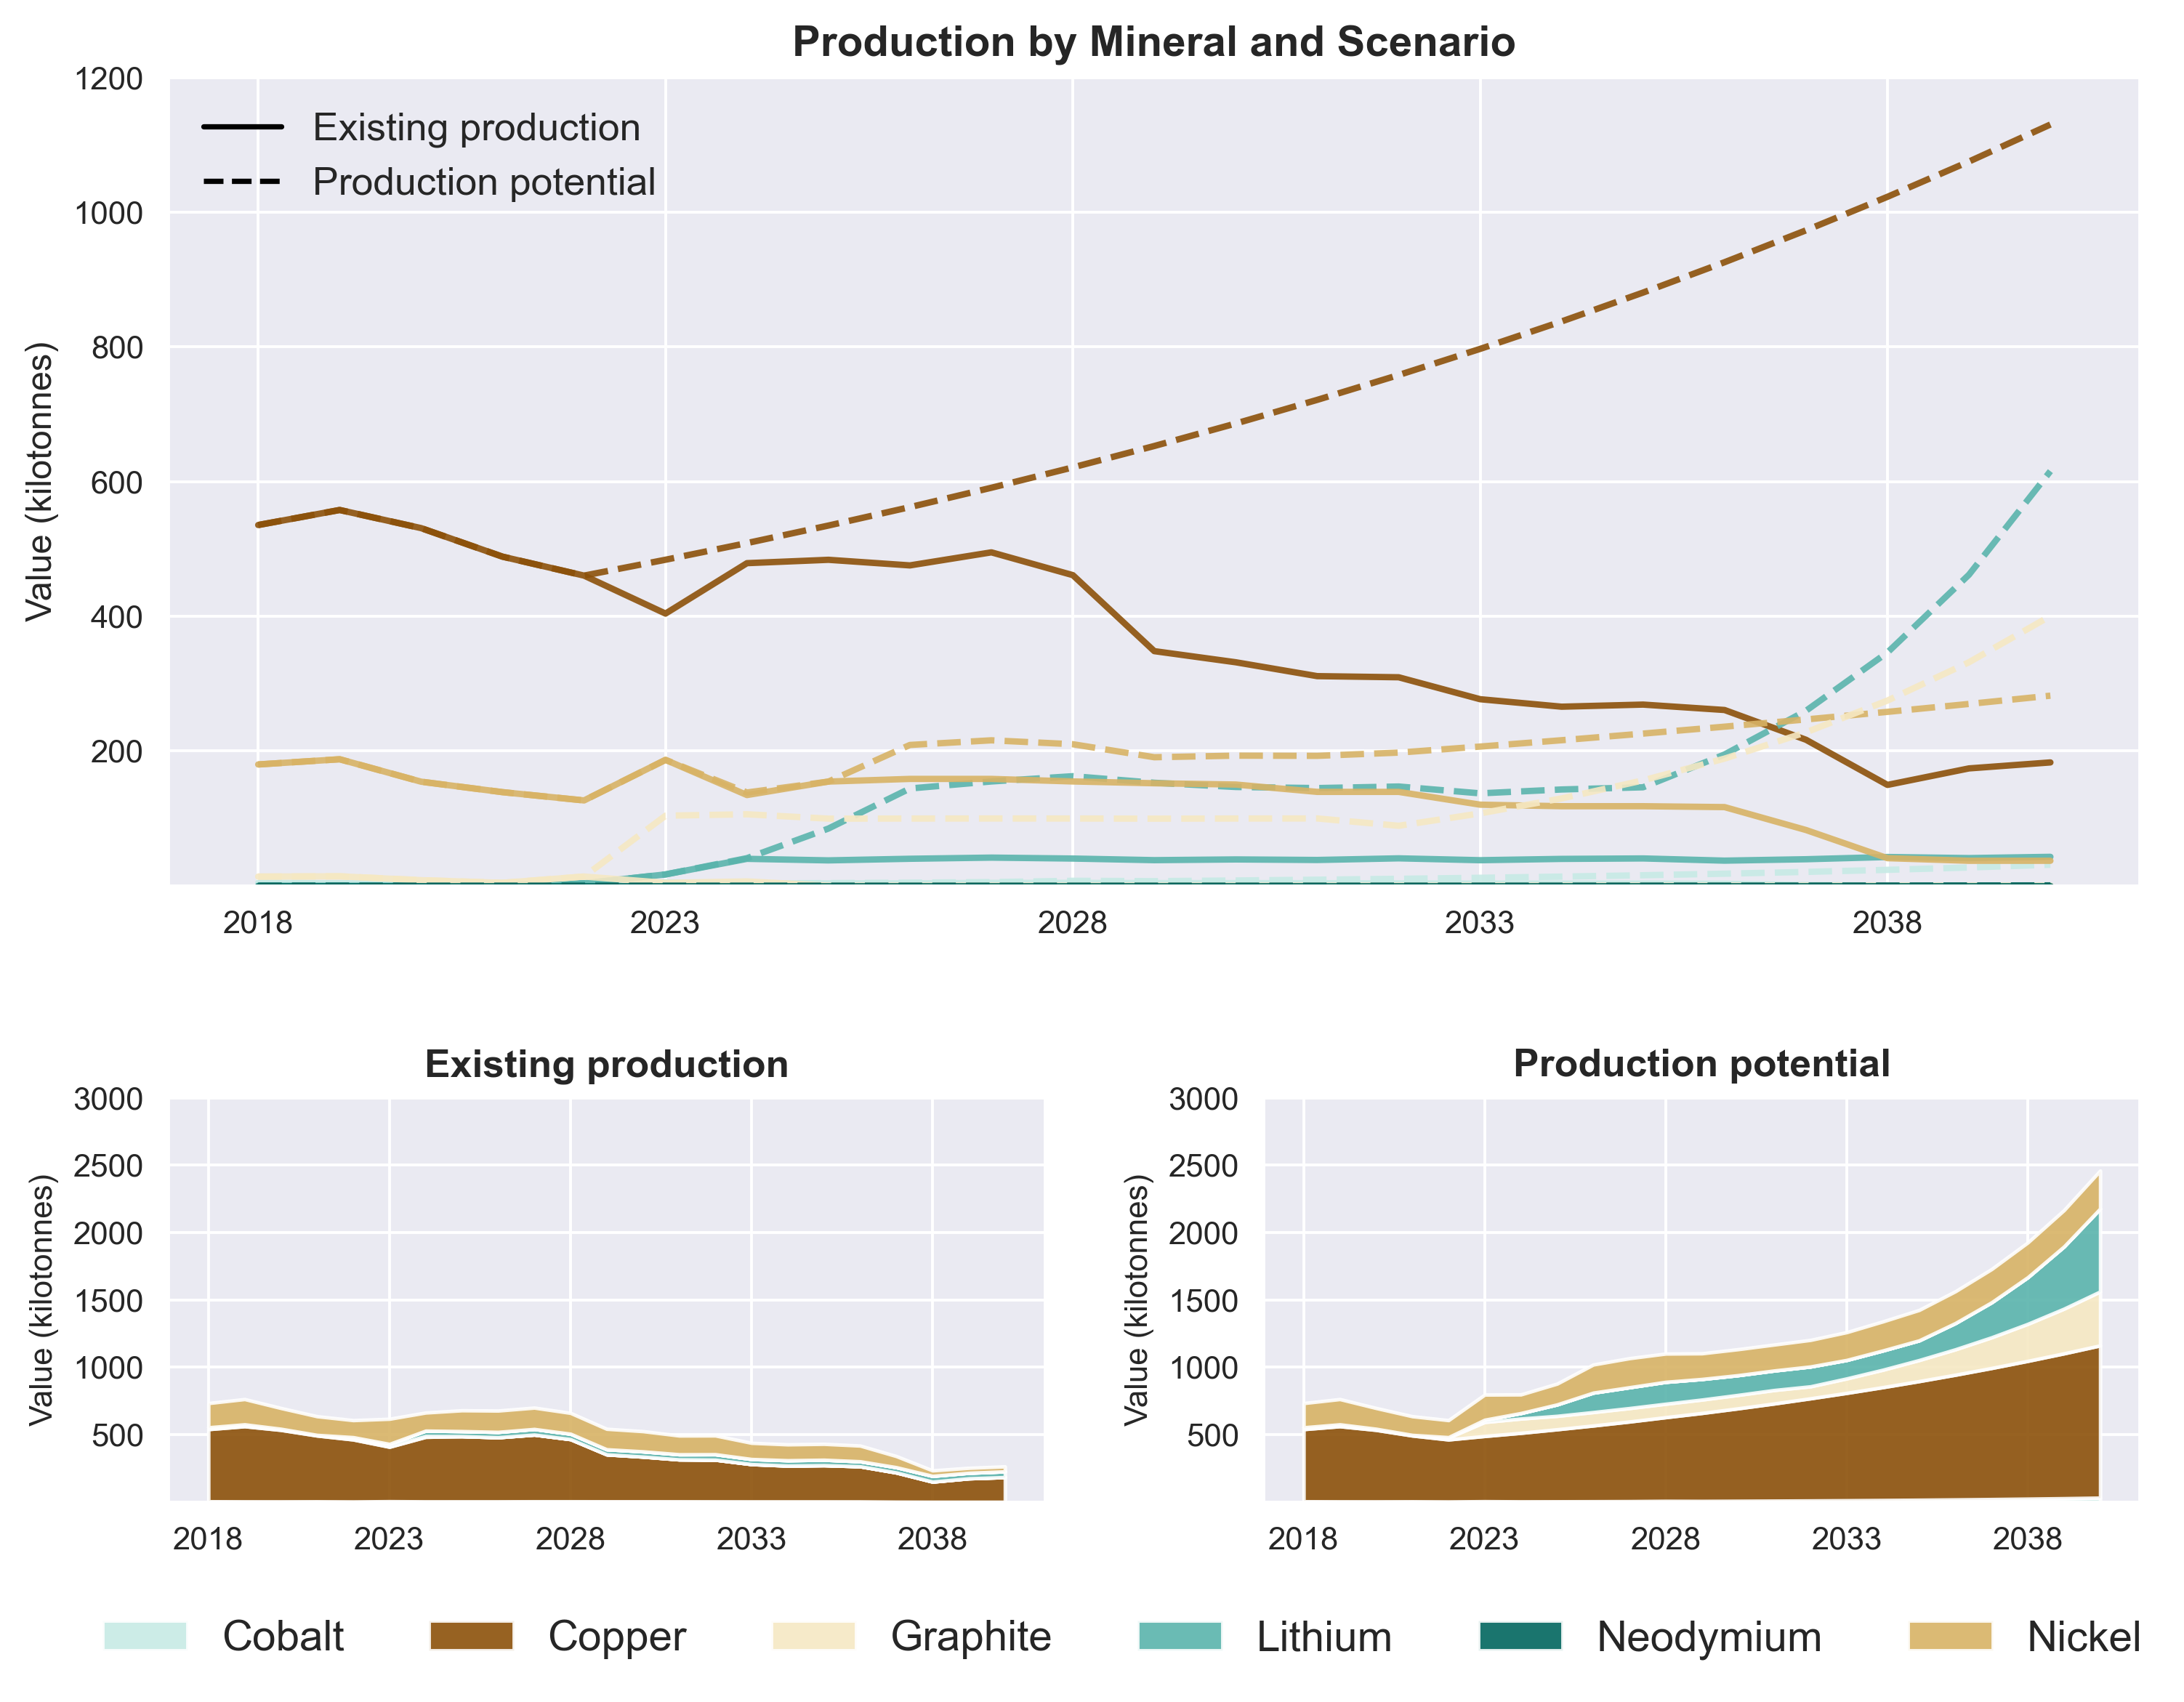

In [13]:
plot_metal_scenarios_panels(cci_df, color_map, savepath="results/Production/production_scenario_mining")